In [5]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
#from tensorflow.keras.layers import Dropout
#from tensorflow.keras.regularizers import L2

# Función para obtener datos históricos de Binance
def get_historical_data(symbol, interval, start_time, end_time):
    url = 'https://api.binance.com/api/v3/klines'
    data = []
    
    # Convertir fechas a timestamps de Unix en milisegundos
    start_time = int(start_time.timestamp() * 1000)
    end_time = int(end_time.timestamp() * 1000)
    
    # Hacer solicitudes a la API en bloques de 1000 velas (límite de Binance)
    while start_time < end_time:
        params = {
            'symbol': symbol,
            'interval': interval,
            'startTime': start_time,
            'endTime': end_time,
            'limit': 1000  # Máximo de velas por solicitud
        }
        response = requests.get(url, params=params)
        chunk = response.json()
        data.extend(chunk)
        
        # Actualizar el start_time para la siguiente solicitud
        if len(chunk) > 0:
            start_time = chunk[-1][0] + 1  # Siguiente milisegundo después de la última vela
        else:
            break
    
    # Convertir los datos en un DataFrame
    columns = [
        'Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
        'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
        'Taker buy quote asset volume', 'Ignore'
    ]
    df = pd.DataFrame(data, columns=columns)
    
    # Convertir tiempos de Unix a fechas legibles
    df['Open time'] = pd.to_datetime(df['Open time'], unit='ms')
    df['Close time'] = pd.to_datetime(df['Close time'], unit='ms')

    # Seleccionar solo las columnas deseadas
    df = df[['Open time', 'Open', 'High', 'Low', 'Close']]
    
    return df

In [7]:
end_time = datetime.strptime('2025-08-01', '%Y-%m-%d')  # Fecha específica
start_time = end_time - timedelta(days=6*365)  # Hace 4 años desde end_time

print("End time:", end_time)
print("Start time:", start_time)

End time: 2025-08-01 00:00:00
Start time: 2019-08-03 00:00:00


In [9]:
SOL_1D = get_historical_data('SOLUSDT', '1d', start_time, end_time)
SOL_1D.head()

,Open time,Open,High,Low,Close
0,2020-08-11,2.85000000,3.52080000,2.84330000,3.29850000
1,2020-08-12,3.29850000,3.92890000,3.08000000,3.75580000
2,2020-08-13,3.75000000,4.13870000,3.50030000,3.73000000
3,2020-08-14,3.72070000,3.76760000,3.32100000,3.40990000
4,2020-08-15,3.41810000,3.74000000,3.15000000,3.17300000


In [7]:
XRP_1D = get_historical_data('XRPUSDT', '1d', start_time, end_time)
XRP_1D.head()

,Open time,Open,High,Low,Close
0,2019-03-04,0.31115000,0.31222000,0.29728000,0.30207000
1,2019-03-05,0.30197000,0.31787000,0.30080000,0.31471000
2,2019-03-06,0.31473000,0.32186000,0.30950000,0.31629000
3,2019-03-07,0.31628000,0.31936000,0.31240000,0.31311000
4,2019-03-08,0.31324000,0.31600000,0.30500000,0.30775000


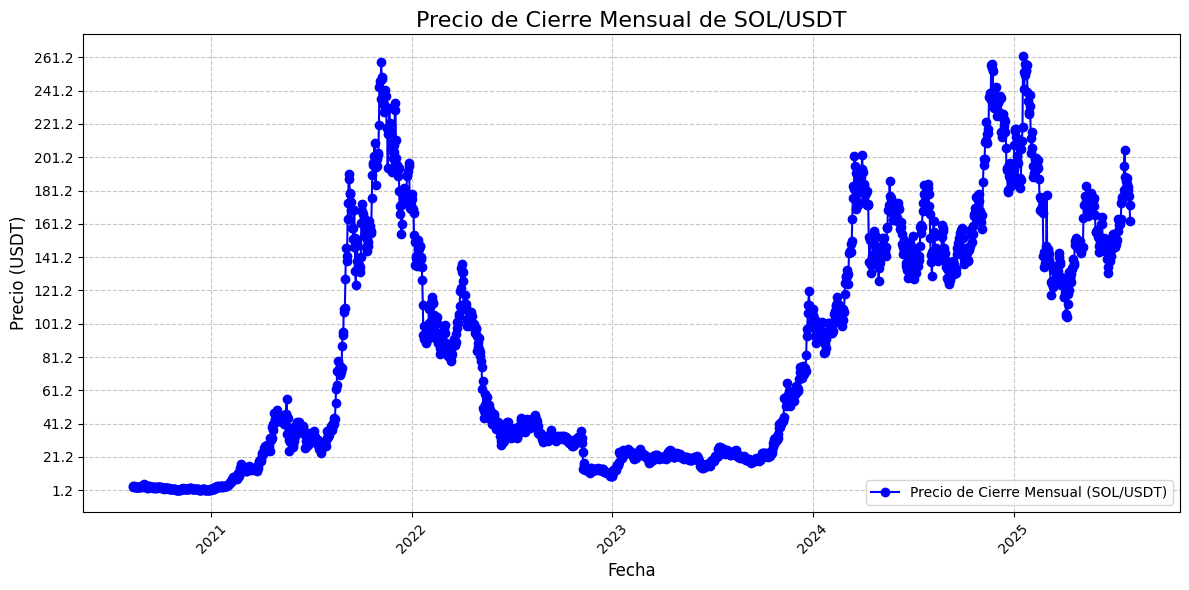

In [10]:
# Convertir 'Open time' a datetime (por si acaso)
SOL_1D['Open time'] = pd.to_datetime(SOL_1D['Open time'])

# Convertir la columna 'Close' a tipo numérico
SOL_1D['Close'] = pd.to_numeric(SOL_1D['Close'], errors='coerce')

# Graficar la serie del precio de cierre mensual
plt.figure(figsize=(12, 6))
plt.plot(SOL_1D['Open time'], SOL_1D['Close'], label='Precio de Cierre Mensual (SOL/USDT)', color='blue', marker='o')

# Definir manualmente las marcas del eje Y
min_y = SOL_1D['Close'].min()  # Valor mínimo del eje Y
max_y = SOL_1D['Close'].max()  # Valor máximo del eje Y
plt.yticks(np.arange(min_y, max_y, step=20))  # Marcas cada 20 unidades

# Personalizar el gráfico
plt.title('Precio de Cierre Mensual de SOL/USDT', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USDT)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Rotar las etiquetas del eje X
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

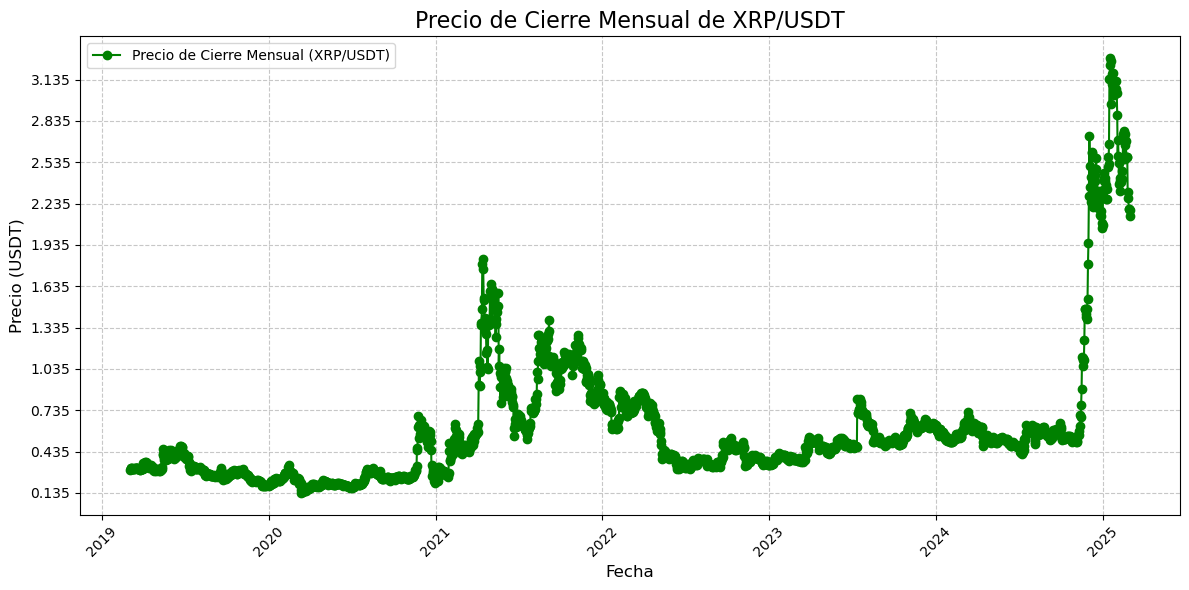

In [21]:
# Convertir 'Open time' a datetime (por si acaso)
XRP_1D['Open time'] = pd.to_datetime(XRP_1D['Open time'])

# Convertir la columna 'Close' a tipo numérico
XRP_1D['Close'] = pd.to_numeric(XRP_1D['Close'], errors='coerce')

# Graficar la serie del precio de cierre mensual
plt.figure(figsize=(12, 6))
plt.plot(XRP_1D['Open time'], XRP_1D['Close'], label='Precio de Cierre Mensual (XRP/USDT)', color='green', marker='o')

# Definir manualmente las marcas del eje Y
min_y = XRP_1D['Close'].min()  # Valor mínimo del eje Y
max_y = XRP_1D['Close'].max()  # Valor máximo del eje Y
plt.yticks(np.arange(min_y, max_y, step=0.3))  

# Personalizar el gráfico
plt.title('Precio de Cierre Mensual de XRP/USDT', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USDT)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Rotar las etiquetas del eje X
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [9]:
# Verificar el rango de fechas
fecha_minima = SOL_1D['Open time'].min()
fecha_maxima = SOL_1D['Open time'].max()

print(f"Fecha mínima: {fecha_minima}")
print(f"Fecha máxima: {fecha_maxima}")

Fecha mínima: 2020-08-11 00:00:00
Fecha máxima: 2025-03-01 00:00:00


In [9]:
# Escalar las columnas numéricas (Open, High, Low, Close)
scaler = MinMaxScaler()
SOL_1D[['Open', 'High', 'Low', 'Close']] = scaler.fit_transform(SOL_1D[['Open', 'High', 'Low', 'Close']])

In [11]:
# Ordenar el DataFrame por fecha (por si acaso no está ordenado)
SOL_1D = SOL_1D.sort_values(by='Open time')

# Dividir los datos en entrenamiento y prueba basado en fechas
split_date = SOL_1D['Open time'].quantile(0.8)  # 80% para entrenamiento, 20% para prueba
train_data = SOL_1D[SOL_1D['Open time'] <= split_date]
test_data = SOL_1D[SOL_1D['Open time'] > split_date]

# Verificar las fechas de entrenamiento y prueba
print(f"Entrenamiento: desde {train_data['Open time'].min()} hasta {train_data['Open time'].max()}")
print(f"Prueba: desde {test_data['Open time'].min()} hasta {test_data['Open time'].max()}")

Entrenamiento: desde 2020-08-11 00:00:00 hasta 2024-04-02 00:00:00
Prueba: desde 2024-04-03 00:00:00 hasta 2025-03-01 00:00:00


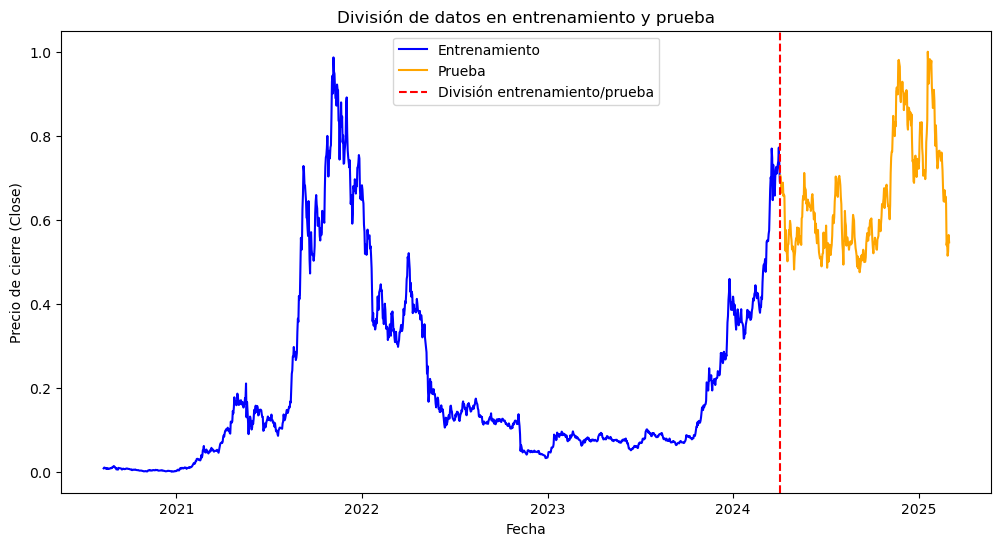

In [43]:
# Graficar los datos de entrenamiento y prueba
plt.figure(figsize=(12, 6))
plt.plot(train_data['Open time'], train_data['Close'], label='Entrenamiento', color='blue')
plt.plot(test_data['Open time'], test_data['Close'], label='Prueba', color='orange')
plt.axvline(x=split_date, color='red', linestyle='--', label='División entrenamiento/prueba')
plt.title('División de datos en entrenamiento y prueba')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (Close)')
plt.legend()
plt.show()

In [13]:
# Crear secuencias para LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)
    
# Crear secuencias para entrenamiento y prueba
seq_length = 30
X_train, y_train = create_sequences(train_data[['Close']].values, seq_length)
X_test, y_test = create_sequences(test_data[['Close']].values, seq_length)

# Verificar y convertir tipos de datos
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

# Verificar y ajustar la forma de los datos
X_train = np.expand_dims(X_train, axis=-1)  # Cambia la forma a (número_de_muestras, 30, 1)
X_test = np.expand_dims(X_test, axis=-1)    # Cambia la forma a (número_de_muestras, 30, 1)

In [27]:
# Definir el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


C:\Users\Javier\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0245 - val_loss: 0.0049
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0020 - val_loss: 0.0048
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017 - val_loss: 0.0038
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0027
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0010 - val_loss: 0.0026
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.5835e-04 - val_loss: 0.0025
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4239e-04 - val_loss: 0.0036
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0770e-04 - val_loss: 0.0023
Epoch 12/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Para LSTM
lstm_predictions = model.predict(X_test)
mse_lstm = mean_squared_error(y_test, lstm_predictions)
print(f'MSE LSTM: {mse_lstm}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
MSE LSTM: 0.0014192820526659489


In [29]:
# Predecir con el modelo entrenado
y_pred = model.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"MSE: {mse}")
print(f"MAE: {mae}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
MSE: 0.00494561530649662
MAE: 0.06004597991704941


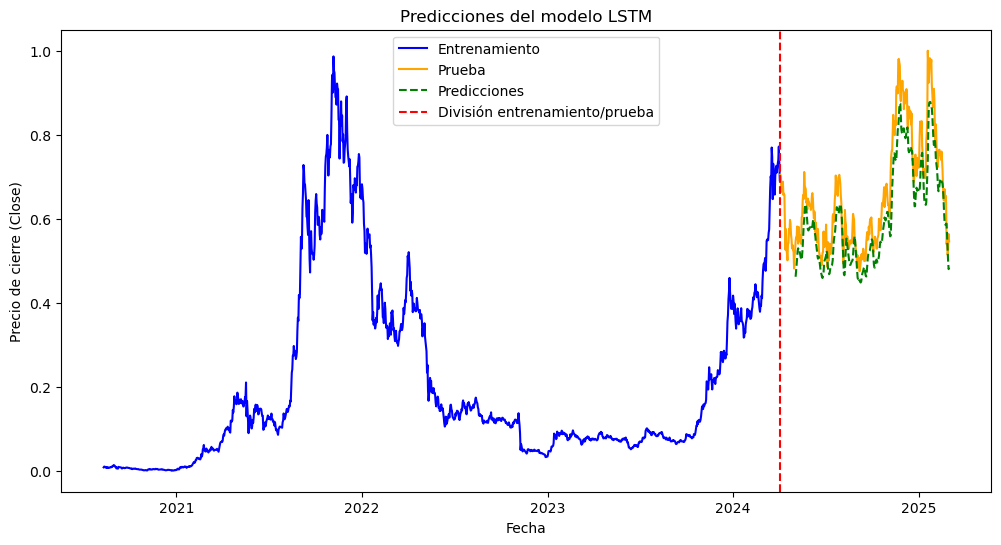

In [39]:
# Crear un DataFrame para las predicciones
predictions_df = pd.DataFrame({
    'Fecha': test_data['Open time'].iloc[seq_length:].reset_index(drop=True),  # Fechas correspondientes
    'Predicción': y_pred.flatten()  # Valores predichos
})

# Graficar los datos de entrenamiento, prueba y predicciones
plt.figure(figsize=(12, 6))

# Datos de entrenamiento
plt.plot(train_data['Open time'], train_data['Close'], label='Entrenamiento', color='blue')

# Datos de prueba
plt.plot(test_data['Open time'], test_data['Close'], label='Prueba', color='orange')

# Predicciones del modelo
plt.plot(predictions_df['Fecha'], predictions_df['Predicción'], label='Predicciones', color='green', linestyle='--')

# Línea vertical para mostrar la división entre entrenamiento y prueba
plt.axvline(x=split_date, color='red', linestyle='--', label='División entrenamiento/prueba')

# Configuración del gráfico
plt.title('Predicciones del modelo LSTM')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (Close)')
plt.legend()
plt.show()

El modelo es capaz de predecir con precisión la tendencia del valor de SOL, lo que resulta fundamental para identificar los momentos más óptimos para comprar o vender. Esta información nos permite tomar decisiones informadas y estratégicas, maximizando el rendimiento de las inversiones al aprovechar los puntos de entrada y salida más favorables en el mercado.

In [49]:
# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.0335e-04 - val_loss: 8.6059e-04
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9765e-04 - val_loss: 8.6729e-04
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.4684e-04 - val_loss: 0.0011
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.8745e-04 - val_loss: 8.4884e-04
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.4210e-04 - val_loss: 8.7274e-04
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.8861e-04 - val_loss: 9.0391e-04
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.1124e-04 - val_loss: 0.0024
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0833e-04 - val_loss: 9.7991e-04
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.6874e-04 - val_loss: 8.4153e-04
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3469e-04 - val_loss: 8.6912e-04
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.8597e-04 - val_

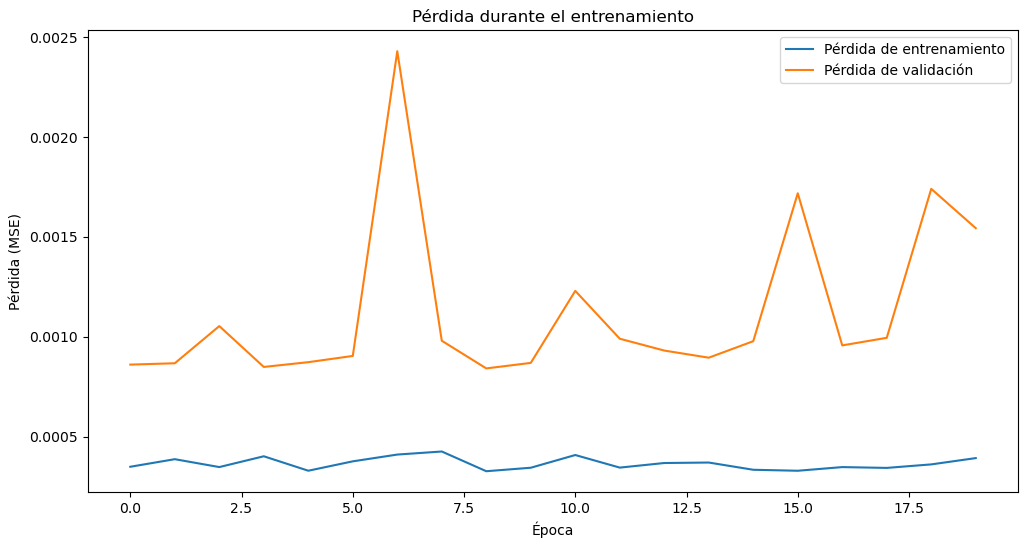

In [51]:
# Graficar la pérdida de entrenamiento y validación
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

El modelo no presenta un sobreajuste severo, pero tampoco está generalizando de manera óptima. La volatilidad en la pérdida de validación sugiere que el modelo es sensible a las variaciones en los datos de validación, lo que podría indicar una falta de robustez. Además, el comportamiento de la pérdida de entrenamiento, al mantenerse constante en un solo valor, sugiere un posible subajuste leve, lo que implica que el modelo podría no estar capturando completamente la complejidad de los datos.

### Aumentar la complejidad del modelo

In [63]:
model2 = Sequential()
model2.add(LSTM(80, return_sequences=True, input_shape=(seq_length, 1)))  # Más neuronas
model2.add(LSTM(80, return_sequences=False))  # Más neuronas
model2.add(Dense(1))

model2.compile(optimizer='adam', loss='mean_squared_error')

history2 = model2.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,  # Reduce el tamaño del batch
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/40


C:\Users\Javier\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0133 - val_loss: 0.0042
Epoch 2/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0031
Epoch 3/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 4/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0045
Epoch 5/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 6/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.7321e-04 - val_loss: 0.0019
Epoch 7/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 0.0025
Epoch 8/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2016e-04 - val_loss: 0.0020
Epoch 9/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.7448e-04 - val_loss: 0.0031
Epoch 10/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.3792e-04 - val_loss: 0.0014
Epoch 11/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.8181e-04 - val_loss: 0.0014
Epoch 12/40
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - 

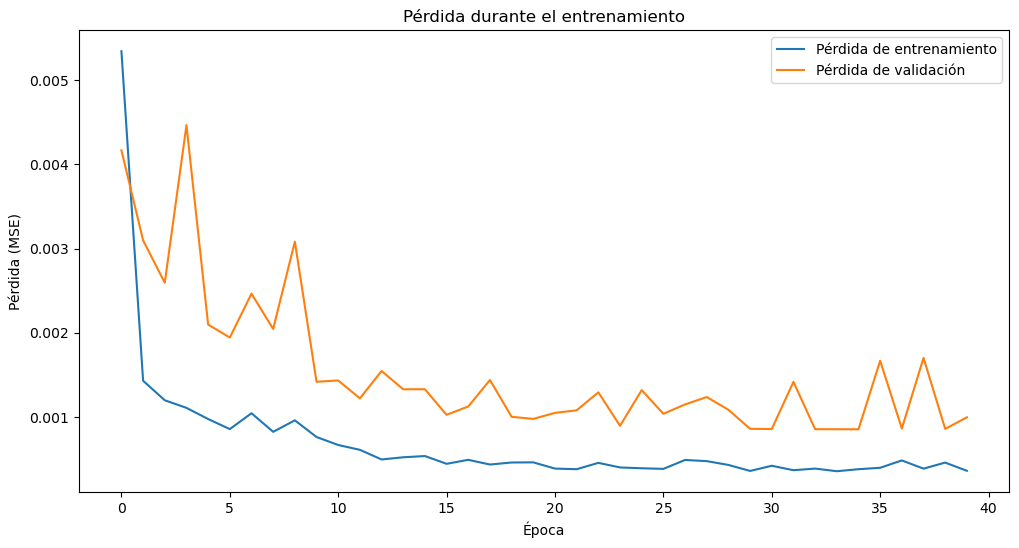

In [64]:
plt.figure(figsize=(12, 6))
plt.plot(history2.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history2.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

El modelo está aprendiendo y generalizando de manera más efectiva en comparación con etapas anteriores. Los picos en la pérdida de validación podrían ser el resultado de:
- Ruido presente en los datos de validación.
- Variaciones naturales en los datos que el modelo aún no ha aprendido completamente.

Sin embargo, la estabilización de ambas curvas (entrenamiento y validación) sugiere que el modelo está convergiendo y alcanzando un punto de equilibrio, lo que indica que está mejorando en su capacidad para generalizar a nuevos datos.

### Suavizar los picos en la pérdida de validación

In [78]:
history3 = model2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16*4,  # Reduce el tamaño del batch
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.9756e-04 - val_loss: 9.0221e-04
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.8566e-04 - val_loss: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.1215e-04 - val_loss: 9.6316e-04
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.3768e-04 - val_loss: 9.3541e-04
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.7798e-04 - val_loss: 9.0190e-04
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.5760e-04 - val_loss: 8.5306e-04
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.7940e-04 - val_loss: 8.4037e-04
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.1306e-04 - val_loss: 8.6871e-04
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.9516e-04 - val_loss: 8.6245e-04
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.1312e-04 - val_loss: 0.0011
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.3331e-04 - val_

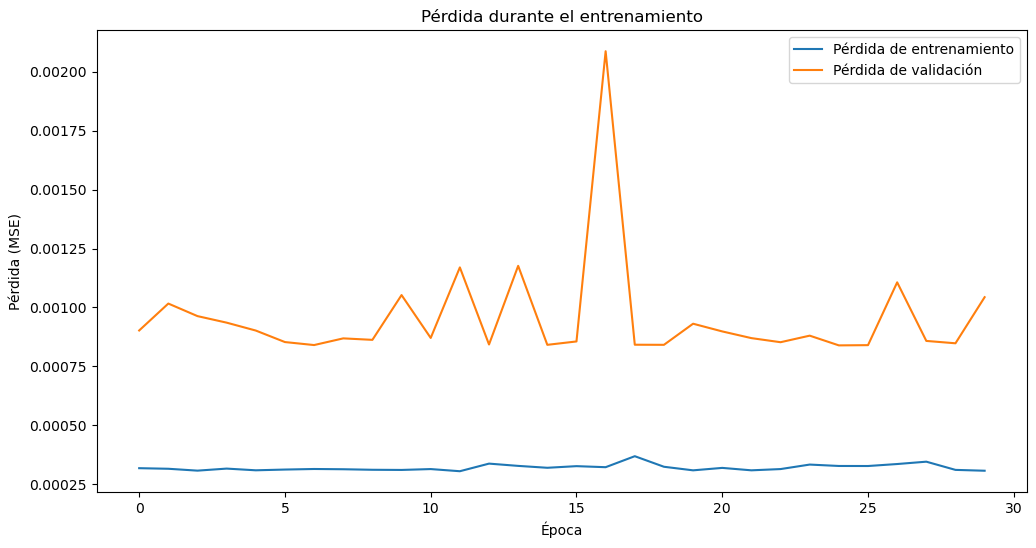

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(history3.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history3.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

In [85]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import L2

model3 = Sequential()
model3.add(LSTM(80, return_sequences=True, input_shape=(seq_length, 1), kernel_regularizer=L2(0.01)))
model3.add(Dropout(0.2))  # Agrega Dropout
model3.add(LSTM(80, return_sequences=False, kernel_regularizer=L2(0.01)))
model3.add(Dropout(0.2))  # Agrega Dropout
model3.add(Dense(1))

model3.compile(optimizer='adam', loss='mean_squared_error')

history4 = model3.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16*4,  # Reduce el tamaño del batch
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30


C:\Users\Javier\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 1.1746 - val_loss: 0.7719
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6720 - val_loss: 0.4309
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3716 - val_loss: 0.2325
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1981 - val_loss: 0.1230
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1036 - val_loss: 0.0749
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0543 - val_loss: 0.0358
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0285 - val_loss: 0.0268
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0170 - val_loss: 0.0141
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0103 - val_loss: 0.0118
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0078 - val_loss: 0.0122
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0072 - val_loss: 0.0201
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0070 - val_l

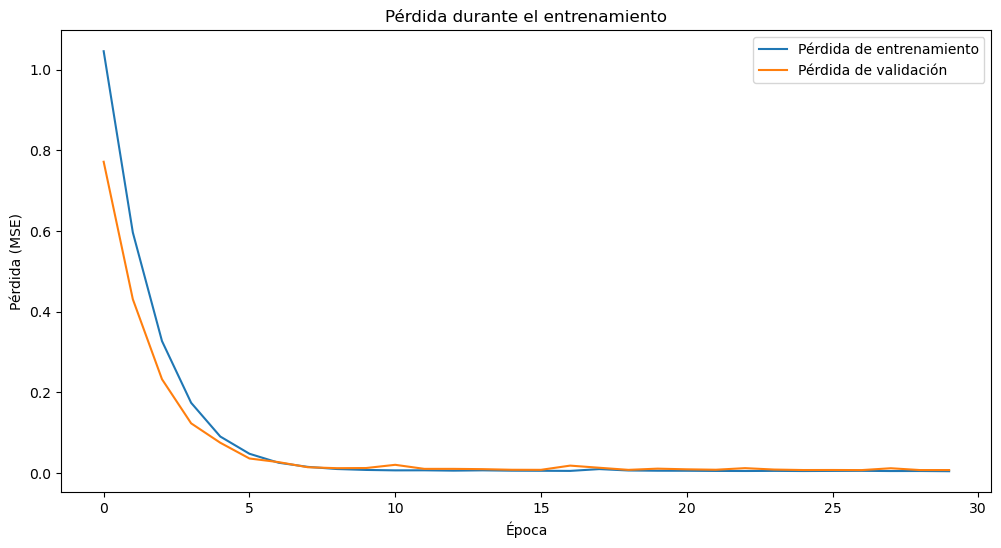

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(history4.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history4.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

El comportamiento actual indica que:

- El modelo está bien ajustado y es capaz de generalizar correctamente a nuevos datos.
- La implementación de Dropout ha sido efectiva para reducir el sobreajuste, lo que ha permitido suavizar las pérdidas y mejorar la robustez del modelo.
- El modelo está listo para ser evaluado en un conjunto de prueba independiente o para realizar predicciones futuras con confianza.

In [90]:
# Predecir en el conjunto de prueba
y_test_pred2 = model3.predict(X_test)

# Calcular métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_test2 = mean_squared_error(y_test, y_test_pred2)
mae_test2 = mean_absolute_error(y_test, y_test_pred2)

print(f"MSE en conjunto de prueba: {mse_test2}")
print(f"MAE en conjunto de prueba: {mae_test2}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
MSE en conjunto de prueba: 0.005767163820564747
MAE en conjunto de prueba: 0.05885330215096474


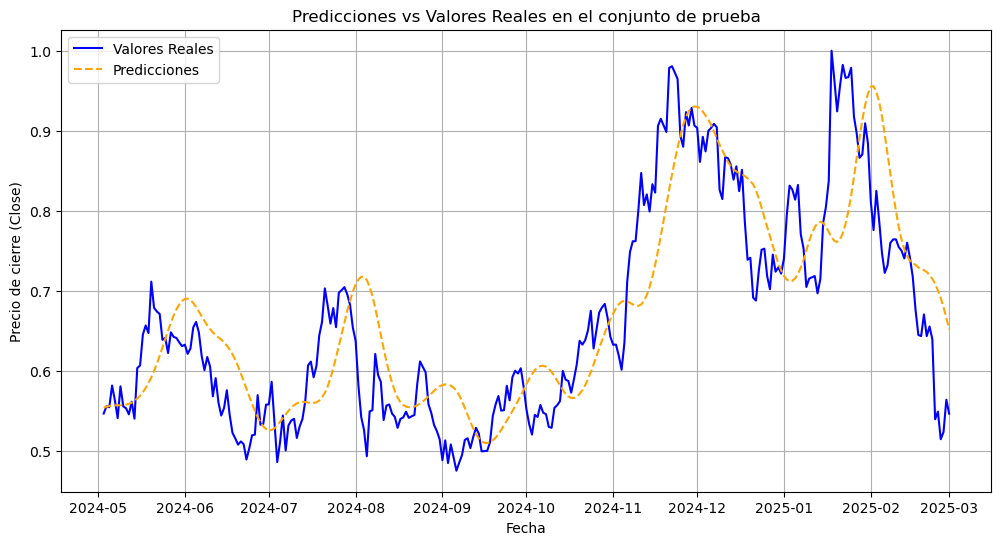

In [92]:
# Crear un DataFrame para facilitar la visualización
results2 = pd.DataFrame({
    'Fecha': test_data['Open time'].iloc[seq_length:].reset_index(drop=True),
    'Real': y_test.flatten(),
    'Predicción': y_test_pred2.flatten()
})

# Graficar valores reales vs predicciones
plt.figure(figsize=(12, 6))
plt.plot(results2['Fecha'], results2['Real'], label='Valores Reales', color='blue')
plt.plot(results2['Fecha'], results2['Predicción'], label='Predicciones', color='orange', linestyle='--')
plt.title('Predicciones vs Valores Reales en el conjunto de prueba')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (Close)')
plt.legend()
plt.grid()
plt.show()

In [37]:
# Redefinir el modelo
model3 = Sequential()
model3.add(LSTM(80, return_sequences=True, input_shape=(30, 1), kernel_regularizer=L2(0.01)))
model3.add(Dropout(0.2))
model3.add(LSTM(80, return_sequences=False, kernel_regularizer=L2(0.01)))
model3.add(Dropout(0.2))
model3.add(Dense(1))

# Compilar el modelo
model3.compile(optimizer='adam', loss='mean_squared_error')

model3.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16*4,  # Reduce el tamaño del batch
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30


C:\Users\Javier\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 1.1983 - val_loss: 0.7837
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6844 - val_loss: 0.4400
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3801 - val_loss: 0.2384
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2034 - val_loss: 0.1267
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1067 - val_loss: 0.0686
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0560 - val_loss: 0.0381
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0299 - val_loss: 0.0233
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0169 - val_loss: 0.0147
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0109 - val_loss: 0.0111
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0090 - val_loss: 0.0108
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0073 - val_loss: 0.0133
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0070 - val_l

In [43]:
seq_length=30

# Obtener los últimos seq_length puntos de la serie
last_sequence = SOL_1D[['Close']].values[-seq_length:]

# Verificar y ajustar la forma
last_sequence = last_sequence.astype('float32')  # Asegurar que sea float32
last_sequence = np.expand_dims(last_sequence, axis=0)  # Cambiar forma a (1, seq_length, 1)
last_sequence

# Número de pasos a predecir (90 días)
n_future = 30*3

# Almacenar las predicciones
future_predictions = []

# Predecir paso a paso
for _ in range(n_future):
    # Predecir
    next_prediction = model3.predict(last_sequence)
    
    # Guardar la predicción
    future_predictions.append(next_prediction[0, 0])
    
    # Actualizar last_sequence
    last_sequence = np.concatenate(
        [last_sequence[:, 1:, :], np.expand_dims([next_prediction[0, 0]], axis=(0, 1))],
        axis=1
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

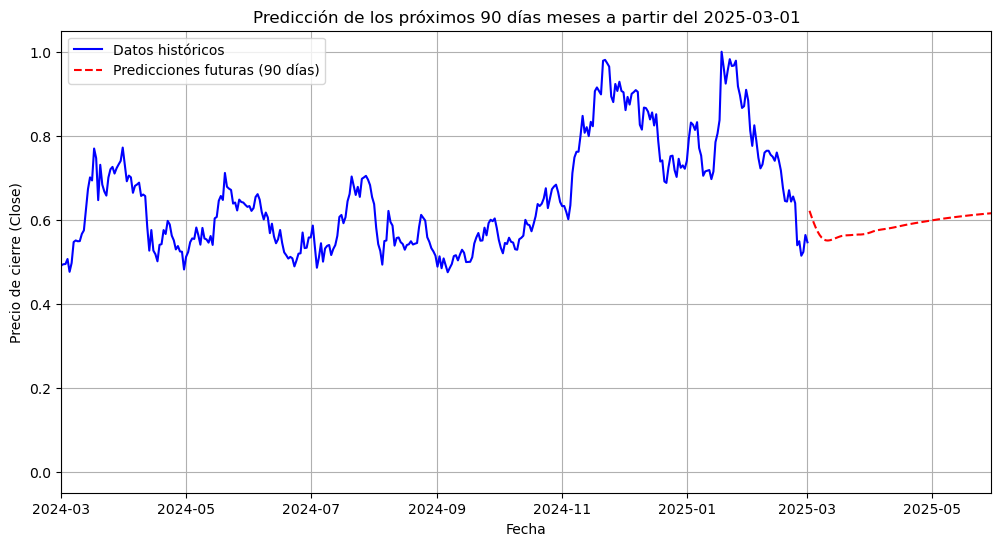

In [45]:
# Generar fechas futuras
last_date = datetime.strptime('2025-03-01', '%Y-%m-%d')
future_dates = [last_date + timedelta(days=i) for i in range(1, n_future + 1)]

# Graficar los datos históricos y las predicciones futuras
plt.figure(figsize=(12, 6))

# Datos históricos
plt.plot(SOL_1D['Open time'], SOL_1D['Close'], label='Datos históricos', color='blue')

# Predicciones futuras
plt.plot(future_dates, future_predictions, label='Predicciones futuras (90 días)', color='red', linestyle='--')

# Configuración del gráfico
plt.title('Predicción de los próximos 90 días meses a partir del 2025-03-01')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (Close)')
plt.legend()
plt.grid()
# Hacer zoom en las predicciones futuras (a partir del 2025-03-01)
plt.xlim([datetime.strptime('2024-03-01', '%Y-%m-%d'), future_dates[-1]])
plt.show()

Se observa en las predicciones que el modelo aun falta por ajustar para dar mejores predicciones, se va aumentar la secuencia a 180 que es la información de 6 meses para comparar si hay mejora o no.

In [48]:
seq_length2 = 30*6
X_train2, y_train2 = create_sequences(train_data[['Close']].values, seq_length2)
X_test2, y_test2 = create_sequences(test_data[['Close']].values, seq_length2)

# Verificar y convertir tipos de datos
X_train2 = X_train2.astype('float32')
y_train2 = y_train2.astype('float32')
X_test2 = X_test2.astype('float32')
y_test2 = y_test2.astype('float32')

# Verificar y ajustar la forma de los datos
X_train2 = np.expand_dims(X_train2, axis=-1)  # Cambia la forma a (número_de_muestras, 30, 1)
X_test2 = np.expand_dims(X_test2, axis=-1)    # Cambia la forma a (número_de_muestras, 30, 1)

In [50]:
# Redefinir el modelo
model4 = Sequential()
model4.add(LSTM(80, return_sequences=True, input_shape=(30, 1), kernel_regularizer=L2(0.01)))
model4.add(Dropout(0.2))
model4.add(LSTM(80, return_sequences=False, kernel_regularizer=L2(0.01)))
model4.add(Dropout(0.2))
model4.add(Dense(1))

# Compilar el modelo
model4.compile(optimizer='adam', loss='mean_squared_error')

model4.fit(
    X_train2, y_train2,
    epochs=30,
    batch_size=16*3,  # Reduce el tamaño del batch
    validation_data=(X_test2, y_test2),
    verbose=1
)

Epoch 1/30


C:\Users\Javier\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 1.1704 - val_loss: 0.7253
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.6174 - val_loss: 0.3725
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.3119 - val_loss: 0.1880
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.1514 - val_loss: 0.0914
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0719 - val_loss: 0.0522
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0344 - val_loss: 0.0255
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0180 - val_loss: 0.0159
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0104 - val_loss: 0.0156
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0087 - val_loss: 0.0212
Epoch 10/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0071 - val_loss: 0.0097
Epoch 11/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0069 - val_loss: 0.0099
Epoch 12/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0070 - val_

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


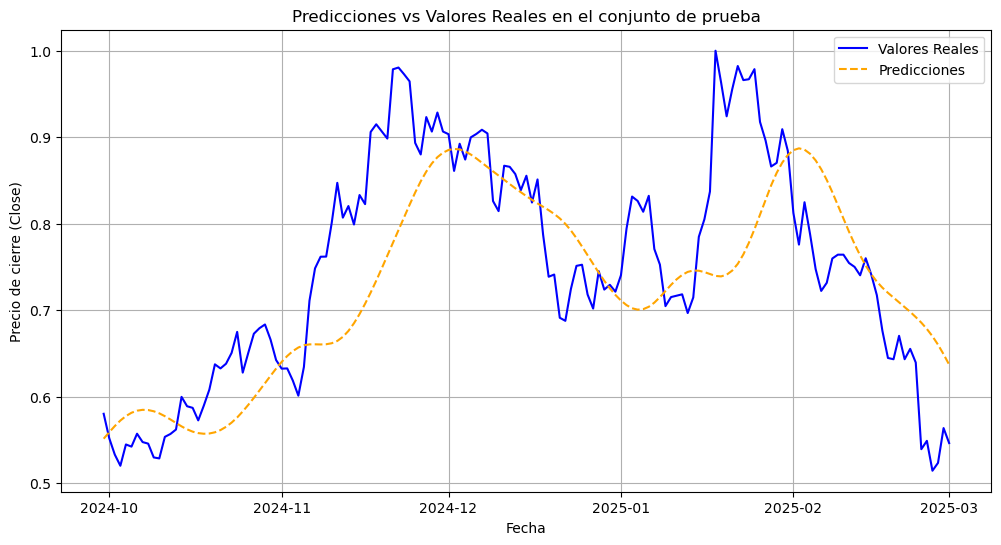

In [54]:
y_test_pred3 = model4.predict(X_test2)

results3 = pd.DataFrame({
    'Fecha': test_data['Open time'].iloc[seq_length2:].reset_index(drop=True),
    'Real': y_test2.flatten(),
    'Predicción': y_test_pred3.flatten()
})

# Graficar valores reales vs predicciones
plt.figure(figsize=(12, 6))
plt.plot(results3['Fecha'], results3['Real'], label='Valores Reales', color='blue')
plt.plot(results3['Fecha'], results3['Predicción'], label='Predicciones', color='orange', linestyle='--')
plt.title('Predicciones vs Valores Reales en el conjunto de prueba')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (Close)')
plt.legend()
plt.grid()
plt.show()

In [64]:
# Redefinir el modelo
model4 = Sequential()
model4.add(LSTM(80, return_sequences=True, input_shape=(30, 1), kernel_regularizer=L2(0.01)))
model4.add(Dropout(0.2))
model4.add(LSTM(80, return_sequences=False, kernel_regularizer=L2(0.01)))
model4.add(Dropout(0.2))
model4.add(Dense(1))

# Compilar el modelo
model4.compile(optimizer='adam', loss='mean_squared_error')

model4.fit(
    X_train2, y_train2,
    epochs=30,
    batch_size=16*3,  # Reduce el tamaño del batch
    validation_data=(X_test2, y_test2),
    verbose=1
)

# Obtener los últimos seq_length puntos de la serie
last_sequence2 = SOL_1D[['Close']].values[-seq_length2:]

# Verificar y ajustar la forma
last_sequence2 = last_sequence2.astype('float32')  # Asegurar que sea float32
last_sequence2 = np.expand_dims(last_sequence2, axis=0)  # Cambiar forma a (1, seq_length, 1)

# Número de pasos a predecir (90 días)
n_future = 30*3

# Almacenar las predicciones
future_predictions2 = []

# Predecir paso a paso
for _ in range(n_future):
    # Predecir
    next_prediction2 = model4.predict(last_sequence2)
    
    # Guardar la predicción
    future_predictions2.append(next_prediction2[0, 0])
    
    # Actualizar last_sequence
    last_sequence2 = np.concatenate(
        [last_sequence2[:, 1:, :], np.expand_dims([next_prediction2[0, 0]], axis=(0, 1))],
        axis=1
    )

Epoch 1/30


C:\Users\Javier\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 1.1733 - val_loss: 0.7293
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.6205 - val_loss: 0.3776
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.3151 - val_loss: 0.1891
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.1546 - val_loss: 0.0981
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0749 - val_loss: 0.0509
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0359 - val_loss: 0.0259
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0193 - val_loss: 0.0166
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0124 - val_loss: 0.0250
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0105 - val_loss: 0.0143
Epoch 10/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0071 - val_loss: 0.0140
Epoch 11/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0063 - val_loss: 0.0094
Epoch 12/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0065 - val_

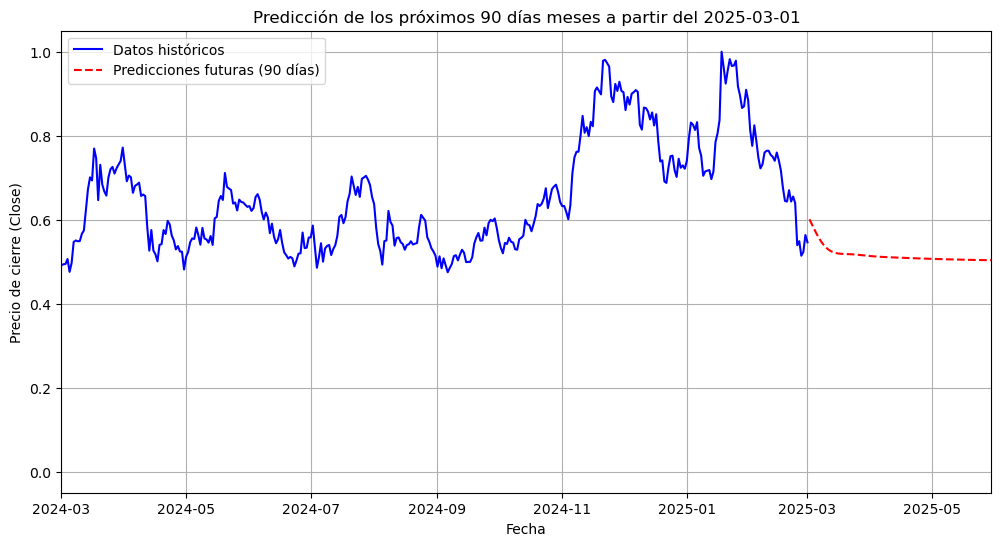

In [68]:
# Generar fechas futuras
last_date = datetime.strptime('2025-03-01', '%Y-%m-%d')
future_dates = [last_date + timedelta(days=i) for i in range(1, n_future + 1)]

# Graficar los datos históricos y las predicciones futuras
plt.figure(figsize=(12, 6))

# Datos históricos
plt.plot(SOL_1D['Open time'], SOL_1D['Close'], label='Datos históricos', color='blue')

# Predicciones futuras
plt.plot(future_dates, future_predictions2, label='Predicciones futuras (90 días)', color='red', linestyle='--')

# Configuración del gráfico
plt.title('Predicción de los próximos 90 días meses a partir del 2025-03-01')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (Close)')
plt.legend()
plt.grid()
# Hacer zoom en las predicciones futuras (a partir del 2025-03-01)
plt.xlim([datetime.strptime('2024-03-01', '%Y-%m-%d'), future_dates[-1]])
plt.show()

Al analizar el comportamiento futuro del valor de la criptomoneda SOL utilizando dos modelos con diferentes secuencias temporales (30 días y 180 días), observamos que las predicciones no coinciden. El modelo basado en una secuencia de 30 días sugiere que el precio de SOL experimentará un aumento en los próximos 90 días, lo que podría indicar una tendencia alcista en el corto plazo. Sin embargo, el modelo que utiliza una secuencia de 180 días proyecta una caída en el valor, sugiriendo una posible tendencia bajista a mediano plazo.

Esta discrepancia entre las predicciones puede ser el resultado de diferencias en los patrones que cada modelo está utilizando para evaluar la información histórica. Mientras que el modelo de 30 días probablemente capta fluctuaciones más recientes y podría estar respondiendo a movimientos más inmediatos del mercado, el modelo de 180 días tiene en cuenta una visión más amplia, que podría estar viendo tendencias a largo plazo o reacciones más estables a eventos macroeconómicos que afectan a SOL.

Es importante considerar que las criptomonedas son extremadamente volátiles y factores externos como decisiones regulatorias, cambios en la adopción tecnológica o fluctuaciones del mercado global pueden influir en el valor de SOL de manera inesperada. Por lo tanto, aunque estos modelos ofrecen perspectivas interesantes, no deben tomarse como predicciones definitivas, sino como herramientas para entender posibles escenarios futuros basados en datos históricos.